In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os

from scipy.ndimage import label, binary_dilation
from scipy.ndimage import distance_transform_edt

import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
# === Paths ===
PATH_ERA5 = '/glade/campaign/cgd/oce/people/rita/ERA5/'  
PATH_corrections = '/glade/campaign/cgd/oce/people/rita/ERA5_bias_correction/T2/' 

# === Year range ===
YEAR_START = 1940
YEAR_FIN = 1979

# YEAR_START = 1980
# YEAR_FIN = 2020

# === Variable settings ===
VAR_NAME = 'T2M'                     # variable name in the forcing files
CORRECTION_VAR = 't2_offset'        # variable name in the correction file

CORRECTION_FILE = 'T2_monthly_mean_offsets_monthly_1958_1979.nc'
# CORRECTION_FILE = 'T2_monthly_mean_offsets_monthly_1980_2015.nc'

In [3]:
mask_era5 = xr.open_dataset(PATH_ERA5 + '1940/194001_hres_cisst.nc', decode_times=False).isel(time=0)
ocean_mask = xr.where(mask_era5.SSTK.notnull(), 1, 0)
# ocean_mask.to_netcdf(PATH_ERA5 + "era5_landsea_mask.nc")

# Exclude areas along the coastline from correction

Text(0.5, 1.0, 'Ocean Weights: Enclosed Basins = 0, Linear Transition from Coast')

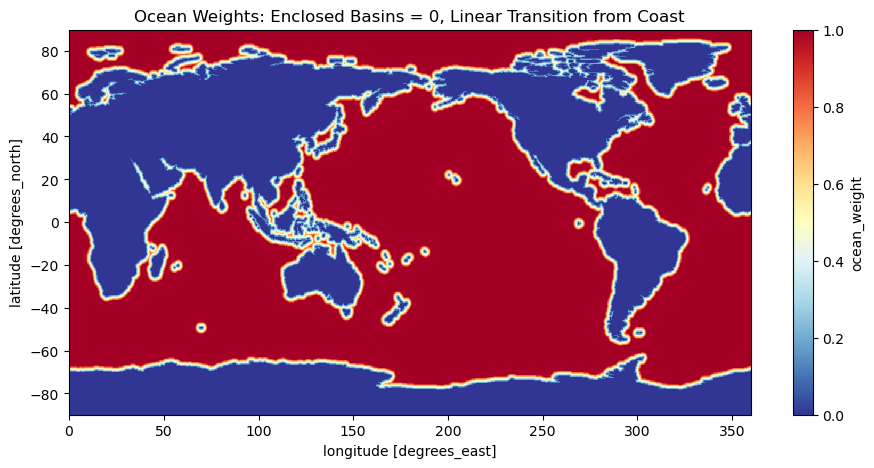

In [4]:
# Step 1: Get the ocean mask as numpy array (1 = ocean, 0 = land)
ocean_np = ocean_mask.values.astype(int)

# Step 1.5: Identify and keep only the largest connected ocean
labeled_ocean, num_features = label(ocean_np)
counts = np.bincount(labeled_ocean.ravel())
largest_ocean_label = counts[1:].argmax() + 1  # skip label=0 (background)
ocean_main = (labeled_ocean == largest_ocean_label).astype(int)  # 1 = main ocean, 0 = enclosed seas

# Step 2: Compute distance from land (land = 1, ocean = 0)
land_mask = ocean_main  # main ocean = 1, everything else = land or masked

# Step 3: Create weight field — linear ramp (e.g. 10 grid points wide)
distance_from_land = distance_transform_edt(land_mask)
weights_np = np.clip(distance_from_land / 10.0, 0, 1)

# Step 4: Mask everything not in main ocean (enclosed seas = 0)
weights_np = weights_np * ocean_main

# Step 5: Wrap as xarray
weights = xr.DataArray(
    weights_np,
    coords=ocean_mask.coords,
    dims=ocean_mask.dims,
    name='ocean_weight'
)

# Step 6: Plot it
plt.figure(figsize=(11, 5))
weights.plot(cmap='RdYlBu_r', vmin=0, vmax=1)
plt.title("Ocean Weights: Enclosed Basins = 0, Linear Transition from Coast")


# Read ERA5 data for every year and apply correction 

In [ ]:
%%time
for year in np.arange(YEAR_START, YEAR_FIN+1):
    print(f"\nProcessing year {year}...")

    # Load hourly data lazily
    hourly_file = os.path.join(PATH_ERA5, f"{year}/{VAR_NAME}_{year}.nc")
    ds_hourly = xr.open_dataset(hourly_file)
    forcing_var = ds_hourly[VAR_NAME]  # shape: (time, lat, lon)

    # Load correction file (monthly, small, eager)
    correction_file = os.path.join(PATH_corrections, CORRECTION_FILE)
    ds_correction = xr.open_dataset(correction_file)
    monthly_correction = ds_correction[CORRECTION_VAR]  # shape: (month, lat, lon)
    # Make sure month dimension is 1-based: 1 to 12

    # List to hold monthly-corrected chunks
    corrected_chunks = []

    # Process each month individually
    for month in range(1, 13):
        print(f"  Correcting month {month:02d}...")

        # Select time steps for this month
        subset = forcing_var.sel(time=forcing_var['time'].dt.month == month)

        if subset.time.size == 0:
            print(f"Warning! No data found for month {month:02d} — skipping.")
            continue

        # Get correction for this month
        correction = monthly_correction.sel(month=month)

        # Subtract correction
        corrected_subset = subset - correction * weights

        # Append to list
        corrected_chunks.append(corrected_subset)

        del subset, correction, corrected_subset

    print('Concatenating all months back into a full year...')
    corrected_full = xr.concat(corrected_chunks, dim='time')
    print('done!')

    corrected_full = corrected_full.drop_vars('month')         
    corrected_full.name = 'T2M'          

    corrected_full = corrected_full.astype('float32')

    # === Save to file ===
    output_file = os.path.join(PATH_ERA5, f"{year}/{VAR_NAME}_{year}_corrected_v1_1958_1979_base_period.nc")
    print(f"Saving to {output_file} ...")
    corrected_full.to_netcdf(output_file, compute=True)

    print("Done!")

    del corrected_full, output_file, monthly_correction, forcing_var



Processing year 1940...
  Correcting month 01...
  Correcting month 02...
  Correcting month 03...
  Correcting month 04...
  Correcting month 05...
  Correcting month 06...
  Correcting month 07...
  Correcting month 08...
  Correcting month 09...
  Correcting month 10...
  Correcting month 11...
  Correcting month 12...
Concatenating all months back into a full year...
done!
Saving to /glade/campaign/cgd/oce/people/rita/ERA5/1940/T2M_1940_corrected_v1_1958_1979_base_period.nc ...
Done!

Processing year 1941...
  Correcting month 01...
  Correcting month 02...
  Correcting month 03...
  Correcting month 04...
  Correcting month 05...
  Correcting month 06...
  Correcting month 07...
  Correcting month 08...
  Correcting month 09...
  Correcting month 10...
  Correcting month 11...
  Correcting month 12...
Concatenating all months back into a full year...
done!
Saving to /glade/campaign/cgd/oce/people/rita/ERA5/1941/T2M_1941_corrected_v1_1958_1979_base_period.nc ...
Done!

Processing 

# Checking the correction

In [10]:
%%time
month = 12

era5_corrected = corrected_full.sel(time=corrected_full['time'].dt.month == month).mean('time')
era5_original = ds_hourly.T2M.sel(time=ds_hourly['time'].dt.month == month).mean('time')

CPU times: user 10.6 s, sys: 10.1 s, total: 20.7 s
Wall time: 1min 25s


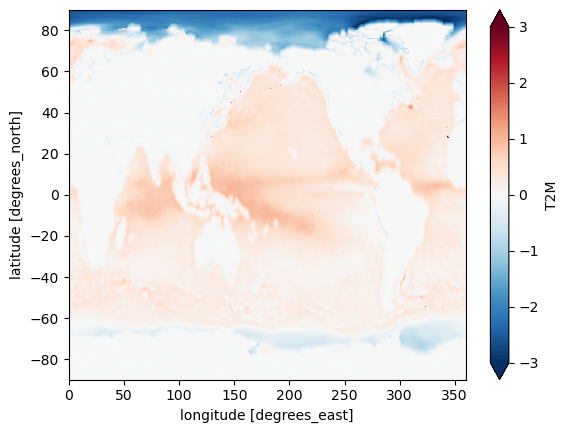

In [11]:
(era5_corrected - era5_original).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')

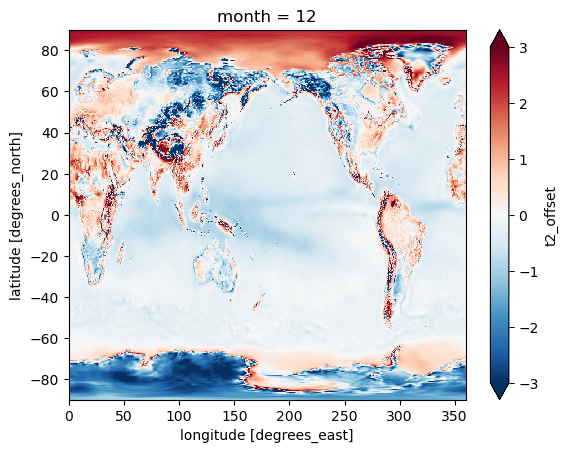

In [12]:
monthly_correction.sel(month = month).plot(vmin = -3, vmax = 3, cmap = 'RdBu_r')